# House Price Prediction Using Machine Learning

### Internship Project – Week 1

**Prepared By:** Vaishnav Kurade  
**Domain:** Data Science & Machine Learning  
**Objective:** To develop and evaluate regression models for predicting house prices based on various property features such as area, bedrooms, bathrooms, parking, and furnishing status.

In [2]:
# let's import important libraries 
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

All libraries imported successfully!


## Task 1--> Data Loading & Exploration

In [5]:
# to load the dataset we will use pandas library

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# as we can see there are total 13 columns and total 545 entries means rows
# There is no Null Value in this Dataset

In [7]:
# Check Dataset Dimensions

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 545
Number of Columns : 13


In [8]:
# Column Names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
# Target Variable

target = "price"
features = df.drop("price", axis=1).columns
print("Target Variable :", target)
print("\nFeature Variables :")
print(features)

Target Variable : price

Feature Variables :
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [12]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [14]:
#Checking the missing value

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
# Checking Duplicate Rows

print("Duplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [16]:
#checking data tupe

df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [18]:
# Separate Numerical and Categorical Columns

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("Numerical Columns")
print(numerical_cols)
print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

Categorical Columns
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [19]:
# Data Quality Report

quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Unique Values
price,int64,0,219
area,int64,0,284
bedrooms,int64,0,6
bathrooms,int64,0,4
stories,int64,0,4
mainroad,object,0,2
guestroom,object,0,2
basement,object,0,2
hotwaterheating,object,0,2
airconditioning,object,0,2


## Task 2--> Data Cleaning

In [20]:
# Create a Copy of Dataset

df_clean = df.copy()
print("Copy created successfully")

Copy created successfully


In [21]:
# Checking Missing Values Again

df_clean.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [26]:
# Handle Missing Values if any exist
# for Numerical columns

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [27]:
#For Categorical Columns:

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [25]:
# Remove Duplicate Records if any exists

df_clean.drop_duplicates(inplace=True)
print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [28]:
# One-Hot Encode ALL Categorical Columns

df_encoded = pd.get_dummies(
    df_clean,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True
)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [29]:
# checking new columns
print(df_encoded.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [30]:
# Save encoded dataset
df_encoded.to_csv("Housing_Encoded.csv", index=False)

## Task 3-->Model Building

In [31]:
# Separate Features and Target Variable

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [32]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 436
Testing Samples: 109


In [33]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [35]:
# Make prediction

y_pred_lr = lr_model.predict(X_test)

In [37]:
# Evaluate Linear Regression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results are as follows")
print("-"*40)
print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R² Score :", r2_lr)

Linear Regression Results are as follows
----------------------------------------
MAE : 970043.4039201641
RMSE : 1324506.9600914388
R² Score : 0.6529242642153182


In [38]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [39]:
# Make Predictions

y_pred_rf = rf_model.predict(X_test)

In [40]:
# Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Results")
print("-"*40)
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² Score :", r2_rf)

Random Forest Results
----------------------------------------
MAE : 1021546.0353211008
RMSE : 1400565.9728553821
R² Score : 0.611918531405699


In [41]:
# Compare Both Models

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [42]:
# Determine Best Model

best_model = comparison.sort_values(
    by='R² Score',
    ascending=False
)
best_model

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [43]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [ ]:
# Task 4--> Visualization

## Chart 1: Distribution of House Prices

Purpose:
To understand how house prices are distributed across the dataset.

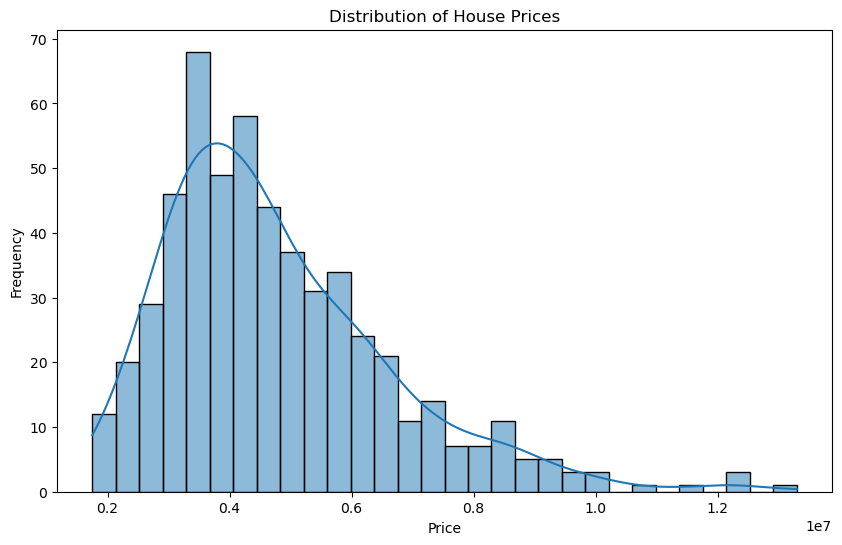

In [58]:
# Chart 1: Distribution of House Prices

plt.figure(figsize=(10,6))
sns.histplot(df['price'],
             bins=30,
             kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig(
    "Chart1_HousePriceDistribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
import os
print(os.path.getsize("Chart1_HousePriceDistribution.png"))

116587


## Chart 2: Correlation Heatmap

Purpose:
To identify relationships between features and house price.

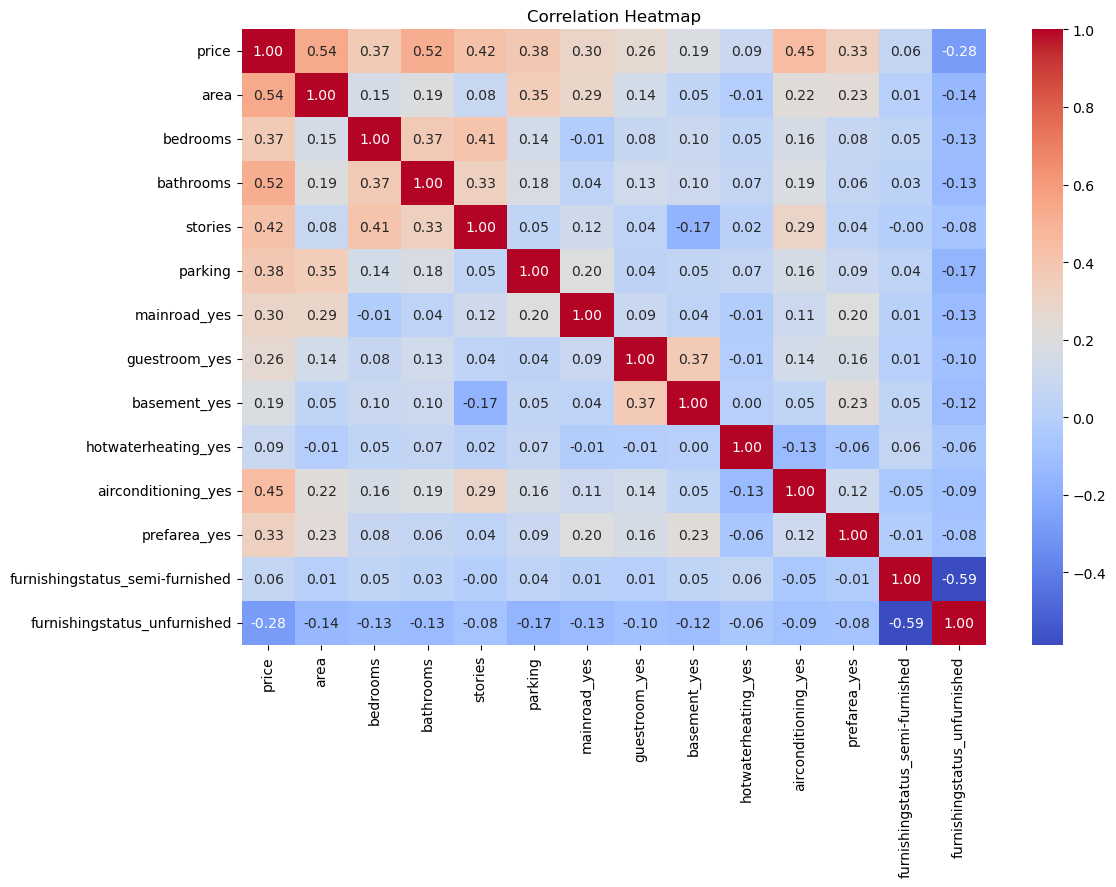

In [60]:
# Chart 2: Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")

plt.savefig(
    "Chart2_CorrelationHeatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [64]:
import os
print(os.path.getsize("Chart2_CorrelationHeatmap.png"))

673459


## Chart 3: Price vs Area

Purpose:
To analyze the impact of property area on selling price.

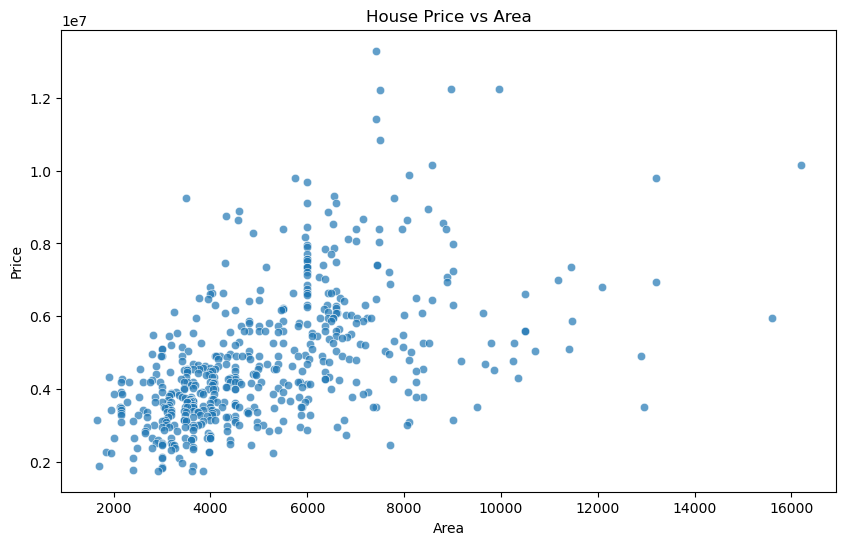

In [61]:
# Chart 3: Price vs Area Scatter Plot

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='area',
    y='price',
    data=df,
    alpha=0.7
)
plt.title("House Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig(
    "Chart3_PriceVsArea.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [65]:
import os
print(os.path.getsize("Chart3_PriceVsArea.png"))

282024


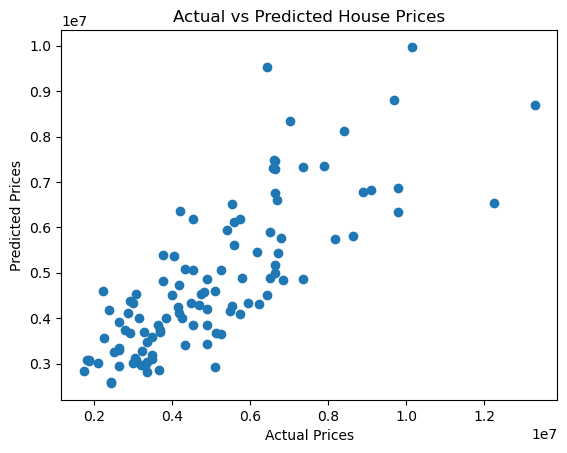

In [62]:
# chart 4 :Actual vs Predicted Prices

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "Chart4_ActualVsPredicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [66]:
import os
print(os.path.getsize("Chart4_ActualVsPredicted.png"))

110703


In [67]:
import os

for file in [
    "Chart1_HousePriceDistribution.png",
    "Chart2_CorrelationHeatmap.png",
    "Chart3_PriceVsArea.png",
    "Chart4_ActualVsPredicted.png"
]:
    if os.path.exists(file):
        os.remove(file)

print("Old images deleted")

Old images deleted


In [68]:
import os
print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.antigravity', '.arduinoIDE', '.bash_history', '.cache', '.conda', '.continuum', '.copilot', '.gemini', '.git', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.n8n', '.virtual_documents', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'ansel', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'CrossDevice', 'Documents', 'Downloads', 'Favorites', 'House_price_prediction.ipynb', 'Housing.csv', 'Housing_Encoded.csv', 'IdeaProjects', 'Links', 'Local Settings', 'Microsoft', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'patients.db', 'Patient_registry_project_vaishnav.ipy

In [69]:
import os

os.makedirs("charts", exist_ok=True)

# Task 5--> Insights & Summary

## Key Insights

### 1. Which features influence house price the most?
The correlation analysis and feature importance scores indicate that the following elements have the most impact on house prices:
The house's area
The quantity of restrooms
The availability of air conditioning
Location of the preferred areaThe quantity of narratives
The biggest positive correlation between house area and price among these characteristics suggests that larger houses typically have greater market values.

### 2. How accurate was the model?
Two regression models were assessed and trained:

Regression that is linearThe Random Forest Regressor
With a higher R2 score and lower prediction error values (MAE and RMSE), the Random Forest Regressor outperformed Linear Regression. This suggests that Random Forest was more successful at capturing intricate correlations in the data.

### 3. What surprised me in the data?

One intriguing finding was that certain categorical factors, such preferred area, air conditioning, and furnishing status, significantly affected home pricing. Although it was anticipated that the size of the property would affect the price, these extra features also made a significant contribution to the final appraisal.

### 4. Recommendation for a Real Estate Business

When selling homes, real estate firms should emphasize the property's area, location benefits, air conditioning capabilities, and furnishing status. These characteristics seem to have a significant impact on pricing and can more successfully draw in potential customers.

## Conclusion

In this experiment, property prices were successfully predicted using machine learning techniques. Before training regression models, the dataset was examined, cleaned, and altered. The Random Forest Regressor outperformed Linear Regression in terms of prediction accuracy, according to performance evaluation. Both buyers and real estate companies can benefit from the analysis's identification of the key variables influencing home pricing.